SCENARIO 1 – K-MEANS(24BAD076)

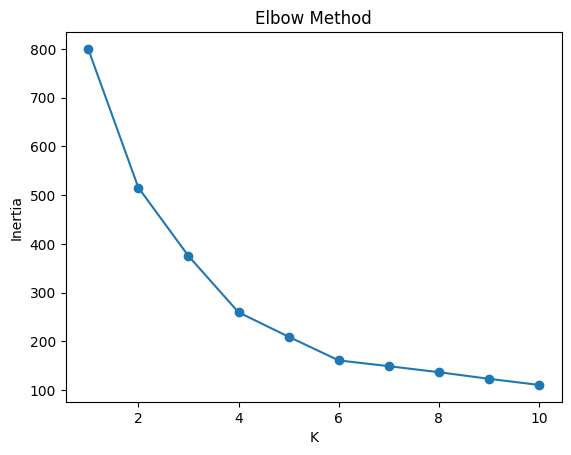

Silhouette Score: 0.4272395443393026


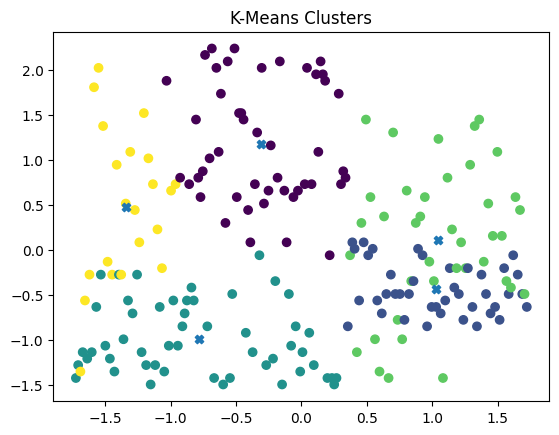

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df = pd.read_csv('Mall_Customers.csv')

df = df.dropna()

X = df.select_dtypes(include=np.number)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure()
plt.plot(k_range, inertia, marker='o')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(X_scaled)

sil_score = silhouette_score(X_scaled, labels)
print("Silhouette Score:", sil_score)

df['Cluster'] = labels

plt.figure()
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker='X')
plt.title('K-Means Clusters')
plt.show()

SCENARIO 2 – GMM(24BAD076)

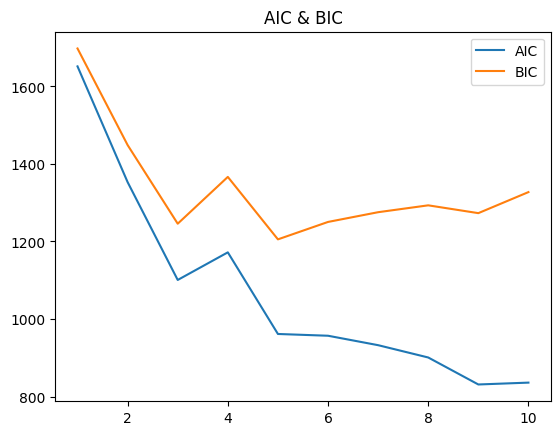

Log Likelihood: -2.0335982199240017
Silhouette Score: 0.3647102145704439


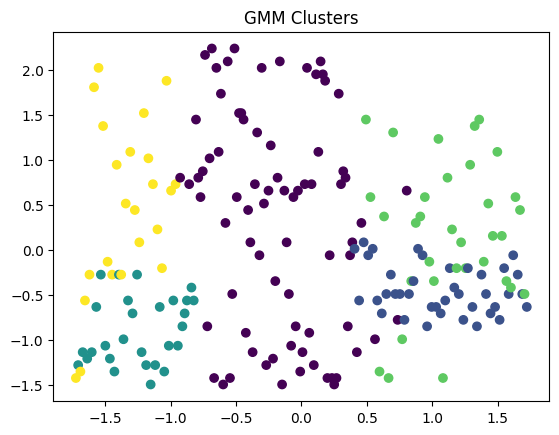

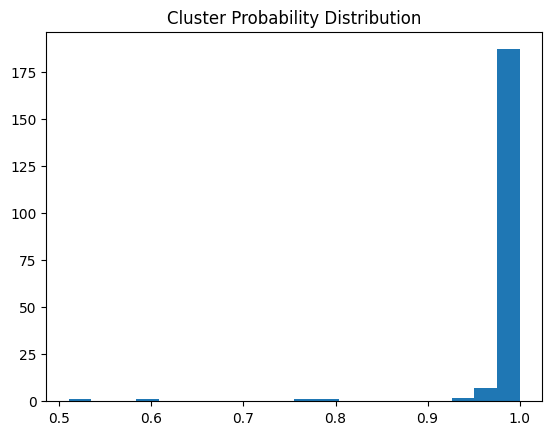

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

df = pd.read_csv('Mall_Customers.csv')

df = df.dropna()

X = df.select_dtypes(include=np.number)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

components = range(1, 11)
aic = []
bic = []

for c in components:
    gmm = GaussianMixture(n_components=c, random_state=42)
    gmm.fit(X_scaled)
    aic.append(gmm.aic(X_scaled))
    bic.append(gmm.bic(X_scaled))

plt.figure()
plt.plot(components, aic, label='AIC')
plt.plot(components, bic, label='BIC')
plt.legend()
plt.title('AIC & BIC')
plt.show()

gmm = GaussianMixture(n_components=5, random_state=42)
gmm.fit(X_scaled)

labels = gmm.predict(X_scaled)
probs = gmm.predict_proba(X_scaled)

print("Log Likelihood:", gmm.score(X_scaled))
print("Silhouette Score:", silhouette_score(X_scaled, labels))

plt.figure()
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels)
plt.title('GMM Clusters')
plt.show()

plt.figure()
plt.hist(probs.max(axis=1), bins=20)
plt.title('Cluster Probability Distribution')
plt.show()